# Notebook 8: Compound Repeats — NW-flex vs BWA-MEM

This notebook is the compound-repeat counterpart to Notebook 7. The setup, scoring scheme, and correctness machinery carry over; what changes is the **structure of the locus**: instead of a single repeat block, the reference contains two adjacent repeat motifs separated by a short interrupting sequence,

$$X = A \cdot R_1^{N_1} \cdot M \cdot R_2^{N_2} \cdot B,$$

and the haplotype varies both repeat counts independently. We sweep $(\Delta_1, \Delta_2)$ and report correctness as a 2-D heatmap, one panel per method.

## What is new and what is reprised

| | Notebook 7 (single block) | Notebook 8 (compound) |
|---|---|---|
| Locus | $X = A \cdot R^N \cdot B$ | $X = A \cdot R_1^{N_1} \cdot M \cdot R_2^{N_2} \cdot B$ |
| Haplotype family | $N + \Delta$ | $(N_1 + \Delta_1, N_2 + \Delta_2)$ |
| NW-flex EP | `build_EP_STR_phase` (one block) | `build_EP_multi_STR_phase` (row-wise union of per-block EP sets) |
| Correctness rule | one zone decoded, outer flanks spanned | both zones decoded, outer flanks spanned; read-level OR over strands |
| Heatmap axes | $\Delta$ × `lflank_extent` | $\Delta_1$ × $\Delta_2$ (one cell aggregates all tiled reads) |

The structural argument from Notebook 7 generalizes: `build_EP_multi_STR_phase` is the row-wise union of per-block EP sets, so an extended NW-flex reference $A \cdot R_1^{3 N_1} \cdot M \cdot R_2^{3 N_2} \cdot B$ is guaranteed to find the optimum over the full Cartesian product of allowed $(N_1 {+} \Delta_1, N_2 {+} \Delta_2)$ counts in a single DP pass. BWA-MEM has no notion of a repeat block at all; with two boundary regions, both can fail, and the failures interact through the local Smith–Waterman landscape.

## Setup

The setup mirrors Notebook 7 — same panel, same BWA-MEM-compatible scoring scheme, same `bwa`/`samtools` runtime requirements.

In [96]:
%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

from nwflex.aligners import RefAligner
from nwflex.default import get_default_scoring
from nwflex.ep_patterns import build_EP_multi_STR_phase

from nwflex.simulation import (
    build_locus_from_panel, clean_flank_window, tile_reads,
    align_bwa, align_bwa_both_strands,
    decode_z_bp, flank_bases_consumed, rc_to_forward_alignment,
    render_zoom, score_alignment,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
# BWA-MEM-compatible scoring (+1 / -4 / -6 / -1) — same as Notebook 7.
score_matrix, gap_open, gap_extend, a2i = get_default_scoring("bwa_mem")
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

In [98]:
required = ("bwa", "samtools")
missing = [t for t in required if shutil.which(t) is None]
if missing:
    print(f"Missing on PATH: {', '.join(missing)}")
    print(f"Install with: conda install -c bioconda {' '.join(missing)}")
    print("BWA-MEM cells will be skipped if these are unavailable.")
else:
    print(f"Found on PATH: {', '.join(required)}")

Found on PATH: bwa, samtools


In [99]:
PANEL_PATH = Path("../data/hg38_motif_sample_K100.tsv")
panel = pd.read_csv(PANEL_PATH, sep="\t")
print(f"Loaded {len(panel):,} loci from {PANEL_PATH}")

Loaded 6,900 loci from ../data/hg38_motif_sample_K100.tsv


## Compound locus construction

We build the compound reference in three pieces: outer flanks, two repeat blocks, and a bridge between them.

- **Outer flanks** $A$ and $B$ are taken from two distinct panel rows. From row 1 we keep the *cleaned* left flank as $A$ (its right edge is guaranteed not to extend $R_1$); from row 2 we keep the *cleaned* right flank as $B$ (its left edge is guaranteed not to extend $R_2$). The cleaning is the same as in Notebook 7 — `build_locus_from_panel` does it.
- **Repeat motifs** $R_1$ and $R_2$ come from the same two panel rows.
- **Bridge** $M$ is composed from the *interior* edges of those two panel flanks (the inner end of row 1's right flank and the inner end of row 2's left flank). Each half is cleaned with `clean_flank_window` against its adjacent motif so the bridge cannot extend either repeat. No new helper is needed — this is two calls to the same function we already use for the outer flanks.

### Source loci, reference counts, and bridge length

We pick a dinucleotide motif for block 1 and a trinucleotide motif for block 2. The reference repeat counts are $N_1 = N_2 = 10$, matching the sweep convention from prior internal compound studies.

The bridge length is set deliberately small. The compound-repeat failure mode for BWA-MEM is a *bridge-anchoring* effect: BWA's seeds need unique non-repeat sequence between the two blocks to disambiguate where each block ends. A short bridge starves the seeder of that anchor, and the local Smith–Waterman extender then has to choose between several near-tied alignments at both block boundaries. With a long bridge BWA recovers cleanly even at large indels — the figure becomes a single-block story with extra steps. We use a 2 bp bridge here so that the compound-specific failure mode is visible.

In [100]:
LOCUS_FLANK_LEN = 200
REF_N1 = 10
REF_N2 = 10
BRIDGE_N1 = 1   # bp from row1's rflank that go into the bridge's left half
BRIDGE_N2 = 1   # bp from row2's lflank that go into the bridge's right half

# Pick two distinct motif lengths so the compound structure is unambiguous.
row1 = panel[panel["type"].str.len() == 2].iloc[0]   # dinucleotide for block 1
row2 = panel[panel["type"].str.len() == 3].iloc[0]   # trinucleotide for block 2

# build_locus_from_panel cleans both flanks of each row; we keep A from row1
# and B from row2.  The motifs come straight from the panel.
locus1 = build_locus_from_panel(
    motif=row1["type"],
    panel_lflank=row1["lflank"],
    panel_rflank=row1["rflank"],
    ref_n=REF_N1,
    flank_len=LOCUS_FLANK_LEN,
)
locus2 = build_locus_from_panel(
    motif=row2["type"],
    panel_lflank=row2["lflank"],
    panel_rflank=row2["rflank"],
    ref_n=REF_N2,
    flank_len=LOCUS_FLANK_LEN,
)
A  = locus1.A
R1 = locus1.R
B  = locus2.B
R2 = locus2.R

print(f"row1 pind={row1['pind']}  motif R1={R1!r}  N1={REF_N1}")
print(f"row2 pind={row2['pind']}  motif R2={R2!r}  N2={REF_N2}")
print(f"  A[-10:] = {A[-10:]!r}   (last base must not be {R1[-1]!r})")
print(f"  B[:10]  = {B[:10]!r}    (first base must not be {R2[0]!r})")

row1 pind=400  motif R1='AC'  N1=10
row2 pind=1480  motif R2='AAC'  N2=10
  A[-10:] = 'GGGCAGACGG'   (last base must not be 'C')
  B[:10]  = 'CATTGACAGG'    (first base must not be 'A')


### Bridge

The bridge $M$ sits between the two blocks. Its left edge is adjacent to $R_1$ on the right side and must not extend $R_1$'s cycle (`M[0] != R_1[0]`); its right edge is adjacent to $R_2$ on the left side and must not extend $R_2$'s cycle (`M[-1] != R_2[-1]`). We compose $M$ from the inner edges of the two panel flanks, cleaning each half against its adjacent motif:

- $M_\text{left}$ = the first `BRIDGE_N1` bp of row 1's right flank, cleaned against $R_1$ (`side="right"`).
- $M_\text{right}$ = the last `BRIDGE_N2` bp of row 2's left flank, cleaned against $R_2$ (`side="left"`).

This is the same `clean_flank_window` we already use for the outer flanks, applied to the inner panel flanks.

In [101]:
bridge_left  = clean_flank_window(R1, row1["rflank"], BRIDGE_N1, side="right")
bridge_right = clean_flank_window(R2, row2["lflank"], BRIDGE_N2, side="left")
M = bridge_left + bridge_right

print(f"Bridge ({len(M)} bp): {M!r}")
print(f"  M[0]  = {M[0]!r}   (must not be {R1[0]!r}, the start of R1)")
print(f"  M[-1] = {M[-1]!r}   (must not be {R2[-1]!r}, the end of R2)")

Bridge (2 bp): 'CA'
  M[0]  = 'C'   (must not be 'A', the start of R1)
  M[-1] = 'A'   (must not be 'C', the end of R2)


### `CompoundLocus`

A small dataclass that bundles the seven pieces $(A, R_1, N_1, M, R_2, N_2, B)$ and exposes the offset arithmetic. The same dataclass models the BWA reference (counts $N_1, N_2$), the NW-flex extended reference (counts $3N_1, 3N_2$), and an individual haplotype (counts $N_1 + \Delta_1, N_2 + \Delta_2$). The properties `sequence`, `flank_len`, and `body_len` are duck-typed for `tile_reads`, so haplotypes drop straight into the existing tiler.

In [102]:
@dataclass(frozen=True)
class CompoundLocus:
    """Compound STR locus  X = A · R1^N1 · M · R2^N2 · B.

    Used for the BWA reference, the NW-flex extended reference, and individual
    haplotypes — the same dataclass with different counts.

    Exposes ``sequence`` / ``flank_len`` / ``body_len`` so it works directly
    with ``tile_reads``.
    """
    A: str
    R1: str
    N1: int
    M: str
    R2: str
    N2: int
    B: str

    @property
    def s1(self) -> int:                # left edge of block 1
        return len(self.A)

    @property
    def e1(self) -> int:                # right edge of block 1
        return self.s1 + len(self.R1) * self.N1

    @property
    def s2(self) -> int:                # left edge of block 2
        return self.e1 + len(self.M)

    @property
    def e2(self) -> int:                # right edge of block 2
        return self.s2 + len(self.R2) * self.N2

    @property
    def X(self) -> str:
        return self.A + self.R1 * self.N1 + self.M + self.R2 * self.N2 + self.B

    @property
    def n(self) -> int:
        return len(self.X)

    # tile_reads-compatible duck-typing.
    @property
    def sequence(self) -> str:
        return self.X

    @property
    def flank_len(self) -> int:
        return len(self.A)

    @property
    def body_len(self) -> int:
        return (
            len(self.R1) * self.N1
            + len(self.M)
            + len(self.R2) * self.N2
        )

    @property
    def blocks(self):
        """Per-block (s, e, k) triples for build_EP_multi_STR_phase."""
        return [
            (self.s1, self.e1, len(self.R1)),
            (self.s2, self.e2, len(self.R2)),
        ]

    @property
    def zones(self):
        """Per-block (z_start, z_end) zones for the correctness check."""
        return ((self.s1, self.e1), (self.s2, self.e2))

### Two references

The BWA reference uses the chosen counts $(N_1, N_2)$. The NW-flex extended reference uses $(3 N_1, 3 N_2)$ so the EP pattern can contract each block to any haplotype count within $[0, 3 N_i]$ — the sweep $\Delta_i \in [-10, 10]$ at $N_i = 10$ sits inside that range, with the boundary cases $\Delta_i = -10$ giving a haplotype with zero copies of $R_i$ and $\Delta_i = +10$ giving twenty.

In [103]:
ref     = CompoundLocus(A=A, R1=R1, N1=REF_N1,     M=M, R2=R2, N2=REF_N2,     B=B)
ref_nwf = CompoundLocus(A=A, R1=R1, N1=3 * REF_N1, M=M, R2=R2, N2=3 * REF_N2, B=B)

print(f"BWA reference     |X|={ref.n} bp")
print(f"  Z1=[{ref.s1},{ref.e1})    Z2=[{ref.s2},{ref.e2})")
print(f"NW-flex extended  |X|={ref_nwf.n} bp")
print(f"  Z1=[{ref_nwf.s1},{ref_nwf.e1})  Z2=[{ref_nwf.s2},{ref_nwf.e2})")

BWA reference     |X|=452 bp
  Z1=[200,220)    Z2=[222,252)
NW-flex extended  |X|=552 bp
  Z1=[200,260)  Z2=[262,352)


## Compound haplotype and reads

The haplotype is the same `CompoundLocus` dataclass, instantiated with $(N_1 + \Delta_1, N_2 + \Delta_2)$. Because `CompoundLocus` exposes `sequence`, `flank_len`, and `body_len`, the existing `tile_reads` works without modification.

For the illustrative figure below we pick one $(\Delta_1, \Delta_2)$ pair away from the diagonal to show alignments that meaningfully exercise both blocks.

In [104]:
DELTA1 = 1     # one extra copy of R1 vs reference
DELTA2 = -1    # one fewer copy of R2 vs reference

hap = CompoundLocus(
    A=A, R1=R1, N1=REF_N1 + DELTA1,
    M=M,
    R2=R2, N2=REF_N2 + DELTA2,
    B=B,
)
truths = (len(R1) * hap.N1, len(R2) * hap.N2)

print(f"Haplotype counts: N1={hap.N1} (Δ1={DELTA1:+d})  N2={hap.N2} (Δ2={DELTA2:+d})")
print(f"  |Hap|={len(hap.sequence)}  body_len={hap.body_len}  flank_len={hap.flank_len}")
print(f"  Truth z_bp:  z1={truths[0]}  z2={truths[1]}")

Haplotype counts: N1=11 (Δ1=+1)  N2=9 (Δ2=-1)
  |Hap|=451  body_len=51  flank_len=200
  Truth z_bp:  z1=22  z2=27


In [105]:
READ_LEN = 150
K_MIN_FLANK = 10

reads = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
print(f"Tiled {len(reads)} reads (read_len={READ_LEN}, k_min_flank={K_MIN_FLANK})")
print(f"  lflank_extent: {min(r.lflank_extent for r in reads)}..{max(r.lflank_extent for r in reads)}")
print(f"  rflank_extent: {min(r.rflank_extent for r in reads)}..{max(r.rflank_extent for r in reads)}")

Tiled 80 reads (read_len=150, k_min_flank=10)
  lflank_extent: 10..89
  rflank_extent: 10..89


## Three alignment configurations on illustrative reads

The three configurations are exactly the same as Notebook 7: BWA-MEM at standard parameters, BWA-MEM with the soft-clip penalty raised so high that clipping never improves the score, and NW-flex with the STR-aware EP pattern. The single change for compound is the EP construction — `build_EP_multi_STR_phase` over the two block triples instead of `build_EP_STR_phase` over one. The `RefAligner` and scoring are identical.

In [106]:
illustrative_idx = [0, len(reads) // 2, len(reads) - 1]
illustrative_reads = [reads[i] for i in illustrative_idx]

res_std    = align_bwa(ref.X, illustrative_reads, no_clip=False)
res_noclip = align_bwa(ref.X, illustrative_reads, no_clip=True)

# BWA-MEM reports the SW (Smith-Waterman / local-extension) score in
# its AS:i: tag.  We rescore each achieved CIGAR using `score_alignment`
# to obtain its NW (Needleman-Wunsch / global) score under the same
# affine-gap parameters with soft-clips treated as free.  The two can
# disagree on boundary reads — BWA's SW max may land at an interior
# cell while the global NW score follows the indel-bearing path through
# the read end.
print("BWA-MEM on three illustrative reads — std (defaults) vs no-clip (-L 500):")
pd.DataFrame({
    ("read",     ""):        illustrative_idx,
    ("lflank",   ""):        [r.lflank_extent for r in illustrative_reads],
    ("rflank",   ""):        [r.rflank_extent for r in illustrative_reads],
    ("cigar",    "std"):     [x.cigar for x in res_std],
    ("cigar",    "no-clip"): [x.cigar for x in res_noclip],
    ("SW score", "std"):     [x.score for x in res_std],
    ("SW score", "no-clip"): [x.score for x in res_noclip],
    ("NW score", "std"):     [
        int(score_alignment(r.sequence, ref.X, x.pos, x.cigar, **sc_kw))
        for r, x in zip(illustrative_reads, res_std)
    ],
    ("NW score", "no-clip"): [
        int(score_alignment(r.sequence, ref.X, x.pos, x.cigar, **sc_kw))
        for r, x in zip(illustrative_reads, res_noclip)
    ],
})

BWA-MEM on three illustrative reads — std (defaults) vs no-clip (-L 500):


read lflank rflank           cigar                 SW score          \
                                 std         no-clip      std no-clip   
0    0     89     10   89M2I22M3D37M   89M2I22M3D37M      131     131   
1   40     49     50   49M2I22M3D77M   49M2I22M3D77M      131     131   
2   79     10     89  10M2I22M3D116M  10M2I22M3D116M      131     131   

  NW score          
       std no-clip  
0      131     131  
1      131     131  
2      131     131

### Two score conventions

The table above reports two different scores for each BWA alignment:

- **SW score** is BWA-MEM's reported `AS:i:` tag — the Smith-Waterman / local-extension score. BWA-MEM extends from a seed and reports the maximum cumulative score it sees *during* extension, which can sit at an interior cell when the optimal global path dips through an indel.

- **NW score** is the Needleman-Wunsch / global score recomputed from the achieved CIGAR by `score_alignment`, using the same match/mismatch/gap parameters with soft-clips treated as free.

For the well-flanked illustrative reads here ($K = 10$, no soft-clips in the achieved CIGARs), the two scores agree. They diverge whenever BWA emits soft-clips, or whenever the SW extender's running maximum lands before the read end — Notebook 7's smaller-flank illustrative trio shows that case directly.

Throughout the rest of this notebook we use the **NW score** whenever we *evaluate* an alignment: it is well-defined for any CIGAR (BWA's output, NW-flex's output, or a constructed truth alignment), and it matches NW-flex's reported `RefAligner` score by construction.

### NW-flex (multi-block) configuration

`build_EP_multi_STR_phase` takes one $(s, e, k)$ triple per block and returns the row-wise union of the per-block phase-preserving EP sets. With one block this degenerates to `build_EP_STR_phase`; with two blocks it lets the same DP pass contract each block independently to any allowed haplotype count.

In [107]:
EP = build_EP_multi_STR_phase(ref_nwf.n, ref_nwf.blocks)

aligner = RefAligner(
    ref=ref_nwf.X,
    extra_predecessors=EP,
    score_matrix=score_matrix,
    gap_open=gap_open,
    gap_extend=gap_extend,
    alphabet_to_index=a2i,
    free_X=True,
    free_Y=True,
    max_read_length=READ_LEN + 5,
)

# NW-flex is a global aligner with the EP-skip extension; its reported
# score equals score_alignment of the same CIGAR under our formula by
# construction, so we label it "NW score" without a separate column.
res_nwflex = [aligner.align_simple(r.sequence) for r in illustrative_reads]
print("NW-flex on three illustrative reads (multi-block EP, 3N per block):")
pd.DataFrame({
    "read":     illustrative_idx,
    "lflank":   [r.lflank_extent for r in illustrative_reads],
    "rflank":   [r.rflank_extent for r in illustrative_reads],
    "cigar":    [a["cigar"] for a in res_nwflex],
    "NW score": [int(a["score"]) for a in res_nwflex],
})

NW-flex on three illustrative reads (multi-block EP, 3N per block):


,read,lflank,rflank,cigar,NW score
0,0,89,10,89M38N24M63N37M,150
1,40,49,50,49M38N24M63N77M,150
2,79,10,89,10M38N24M63N116M,150


### A closer look at the alignments

Compound CIGARs are easier to read with two zooms on the same alignment — one centered on $Z_1$, one on $Z_2$. The `|` markers denote the flank/repeat/middle/repeat/flank transitions that fall within each window.

In [108]:
def _print_zooms(label, ref_seq, read_seq, pos, cigar, zones):
    print(f"  {label}  {cigar}")
    for z_label, (z_start, z_end) in zip(("Z1", "Z2"), zones):
        block = render_zoom(ref_seq, read_seq, pos, cigar, z_start, z_end)
        print(f"    {z_label}:")
        for line in block.splitlines():
            print(f"      {line}")

for ix, r, s, n, w in zip(illustrative_idx, illustrative_reads,
                          res_std, res_noclip, res_nwflex):
    print(f"Read idx={ix}   lflank={r.lflank_extent:>3}   rflank={r.rflank_extent:<3}")
    _print_zooms("BWA std   ", ref.X,     r.sequence, s.pos,        s.cigar,        ref.zones)
    _print_zooms("BWA noclip", ref.X,     r.sequence, n.pos,        n.cigar,        ref.zones)
    _print_zooms("NW-flex   ", ref_nwf.X, r.sequence, w["start_pos"], w["cigar"], ref_nwf.zones)
    print()

Read idx=0   lflank= 89   rflank=10 
  BWA std     89M2I22M3D37M
    Z1:
      ref :  CAGGTGGGCAGACGG|--ACACACACACACACACACAC|CAAACAACAACAACA
      read:  CAGGTGGGCAGACGG|ACACACACACACACACACACAC|CA---AACAACAACA
                             II                       DDD          
    Z2:
      ref :  CACACACACACACCA|AACAACAACAACAACAACAACAACAACAAC|CATTGACAGG
      read:  CACACACACACACCA|---AACAACAACAACAACAACAACAACAAC|CATTGACAGG
                             DDD                                      
  BWA noclip  89M2I22M3D37M
    Z1:
      ref :  CAGGTGGGCAGACGG|--ACACACACACACACACACAC|CAAACAACAACAACA
      read:  CAGGTGGGCAGACGG|ACACACACACACACACACACAC|CA---AACAACAACA
                             II                       DDD          
    Z2:
      ref :  CACACACACACACCA|AACAACAACAACAACAACAACAACAACAAC|CATTGACAGG
      read:  CACACACACACACCA|---AACAACAACAACAACAACAACAACAAC|CATTGACAGG
                             DDD                                      
  NW-flex     89M38N24M63N37M
    Z1:
   

## Correctness rule and truth alignments

Notebook 7's per-arm correctness check `is_arm_correct` decoded one zone and required the alignment to span the outer flanks. The compound rule is the natural generalization:

1. Each zone $Z_i$ must decode to its truth $z_i^{\text{truth}}$ — both, not either.
2. The alignment must span the outer flanks: at least one reference base consumed left of $Z_1$ and one right of $Z_2$. The bridge $M$ sits between $Z_1$ and $Z_2$ and is not counted as flank by this check — `flank_bases_consumed` against the outermost zone window does the right thing.

For BWA we run both orientations as in Notebook 7. The read-level credit rule is: a read is correct iff *one strand* recovers *both* numbers and spans the outer flanks. We do not OR per-zone across strands, only per-read.

Notebook 7 also surfaces an **NW (truth)** column alongside the achieved NW score. NW (truth) is the NW score that `score_alignment` assigns to the natural truth CIGAR — the alignment that puts each block's count difference at its block boundary (BWA, against the locus reference) or absorbs each block's unused motifs into a free EP skip (NW-flex, against the 3N reference). Those package-level helpers (`bwa_truth_cigar`, `nwflex_truth_cigar`) are single-block; the compound analogues live inline below. Where the achieved NW score *exceeds* NW (truth), the aligner found a strictly higher-scoring path than the truth — typically by absorbing some boundary mass into mismatches or alternative indels. Where the two agree, the truth is at least co-optimal.

In [109]:
def is_arm_correct_multi(cigar, start_pos_1based, zones, truths,
                         *, convention, min_flank=1):
    """Multi-zone version of nwflex.simulation.is_arm_correct.

    All zones must decode correctly under ``convention``; outer-flank
    coverage is checked against the outermost zone (left edge of zones[0],
    right edge of zones[-1]).  Returns False on unmapped reads.
    """
    if cigar is None or start_pos_1based is None:
        return False
    for (z_start, z_end), truth in zip(zones, truths):
        z_bp = decode_z_bp(
            cigar, start_pos_1based, z_start, z_end, convention=convention
        )
        if z_bp != truth:
            return False
    z_outer_start = zones[0][0]
    z_outer_end   = zones[-1][1]
    left, right = flank_bases_consumed(
        cigar, start_pos_1based, z_outer_start, z_outer_end,
    )
    return left >= min_flank and right >= min_flank


def is_read_correct_bwa_compound(both, zones, truths, ref_length,
                                 *, min_flank=1):
    """Boolean both-strands BWA verdict (used by the illustrative table)."""
    fwd_ok = is_arm_correct_multi(
        both.fwd.cigar, both.fwd.pos, zones, truths,
        convention="bwa", min_flank=min_flank,
    )
    if both.rc.cigar is None or both.rc.pos is None:
        rc_ok = False
    else:
        rc_pos, rc_cigar = rc_to_forward_alignment(
            both.rc.pos, both.rc.cigar, ref_length,
        )
        rc_ok = is_arm_correct_multi(
            rc_cigar, rc_pos, zones, truths,
            convention="bwa", min_flank=min_flank,
        )
    return fwd_ok or rc_ok


# Four-state classification — matches NB7's alignment_state /
# bwa_state_both_strands but generalised to multi-zone correctness.
_STATE_PRIORITY = {"P": 0, "T": 1, "M": 2, "D": 3}


def alignment_state_multi(cigar, pos_1based, chosen_score, truth_score,
                          zones, truths, *, convention, min_flank=1):
    """Multi-zone version of nwflex.simulation.alignment_state.

    Returns "P" (Pass), "T" (Tied co-optimal), "M" (Missed; truth strictly
    dominates), or "D" (Dominated; chosen strictly preferred).  Unmapped or
    score-less inputs classify as "D".
    """
    if cigar is None or pos_1based is None or chosen_score is None:
        return "D"
    if is_arm_correct_multi(cigar, pos_1based, zones, truths,
                            convention=convention, min_flank=min_flank):
        return "P"
    if chosen_score > truth_score:
        return "D"
    if chosen_score < truth_score:
        return "M"
    return "T"


def worst_state(states):
    """Highest-priority state across an iterable (D > M > T > P).

    Used to aggregate per-strand classifications across the many reads in
    one (Δ1, Δ2) cell — any read failure surfaces in the cell summary.
    """
    return max(states, key=lambda s: _STATE_PRIORITY[s])

In [110]:
def _build_compound_cigar(segments):
    """Build a CIGAR string from a sequence of (length, op) pairs, merging
    consecutive ``M`` runs and skipping zero-length segments."""
    out = []
    for length, op in segments:
        if length == 0:
            continue
        if op == "M" and out and out[-1][1] == "M":
            out[-1] = (out[-1][0] + length, "M")
        else:
            out.append((length, op))
    return "".join(f"{l}{op}" for l, op in out)


def bwa_truth_cigar_compound(read, hap_compound, ref_compound):
    """Natural truth CIGAR for compound BWA alignment.

    Each block's count difference sits as a single I or D at the block's
    left boundary; the bridge contributes M ops that merge with the
    surrounding body matches.  Mismatches in the haplotype (none in this
    notebook) would sit inside the M runs and be priced by score_alignment.
    """
    L  = read.lflank_extent
    Rf = read.rflank_extent
    body1_hap = len(hap_compound.R1) * hap_compound.N1
    body1_ref = len(ref_compound.R1) * ref_compound.N1
    body2_hap = len(hap_compound.R2) * hap_compound.N2
    body2_ref = len(ref_compound.R2) * ref_compound.N2
    M_len = len(ref_compound.M)
    d1 = body1_hap - body1_ref
    d2 = body2_hap - body2_ref

    pos = (ref_compound.s1 - L) + 1
    segments = [(L, "M")]
    if d1 > 0:
        segments.append((d1, "I"))
        segments.append((body1_ref, "M"))
    elif d1 < 0:
        segments.append((-d1, "D"))
        segments.append((body1_hap, "M"))
    else:
        segments.append((body1_ref, "M"))
    segments.append((M_len, "M"))
    if d2 > 0:
        segments.append((d2, "I"))
        segments.append((body2_ref, "M"))
    elif d2 < 0:
        segments.append((-d2, "D"))
        segments.append((body2_hap, "M"))
    else:
        segments.append((body2_ref, "M"))
    segments.append((Rf, "M"))
    return pos, _build_compound_cigar(segments)


def nwflex_truth_cigar_compound(read, hap_compound, nwflex_ref_compound):
    """Natural truth CIGAR for compound NW-flex alignment against the 3N
    extended reference: each block's unused motifs are absorbed into a
    free EP skip (``N`` op)."""
    L  = read.lflank_extent
    Rf = read.rflank_extent
    body1_hap = len(hap_compound.R1) * hap_compound.N1
    body2_hap = len(hap_compound.R2) * hap_compound.N2
    body1_ref = len(nwflex_ref_compound.R1) * nwflex_ref_compound.N1
    body2_ref = len(nwflex_ref_compound.R2) * nwflex_ref_compound.N2
    M_len = len(nwflex_ref_compound.M)
    skip1 = body1_ref - body1_hap
    skip2 = body2_ref - body2_hap
    if skip1 < 0 or skip2 < 0:
        raise ValueError(
            f"haplotype block exceeds NW-flex 3N reference: "
            f"skip1={skip1}, skip2={skip2}"
        )

    pos = (nwflex_ref_compound.s1 - L) + 1
    segments = [(L, "M")]
    if skip1 > 0:
        segments.append((skip1, "N"))
    segments.append((body1_hap, "M"))
    segments.append((M_len, "M"))
    if skip2 > 0:
        segments.append((skip2, "N"))
    segments.append((body2_hap, "M"))
    segments.append((Rf, "M"))
    return pos, _build_compound_cigar(segments)

### Verdicts on the illustrative reads

A side-by-side table of CIGARs, SW/NW scores, NW (truth), and the correctness verdict for each method. The BWA cells use the `bwa` boundary convention; the NW-flex cell uses `nwflex`.

The **SW score** comes from BWA's `AS:i:` tag. The **NW score** is recomputed from each achieved CIGAR via `score_alignment` under the shared scoring scheme (and is what NW-flex reports directly). The **NW (truth)** column is the NW score of the natural compound truth CIGAR — the alignment that places each block's count difference at its block boundary (BWA) or absorbs the unused motifs into a free EP skip (NW-flex). Where an achieved NW score exceeds NW (truth), the aligner found a strictly higher-scoring path than the truth. Where they agree, the truth is at least co-optimal.

In [111]:
zones_bwa      = ref.zones
zones_nwf      = ref_nwf.zones
ref_length_bwa = ref.n

# Re-run BWA in both-strands mode so the verdict matches the sweep.
both_std_ill = align_bwa_both_strands(ref.X, illustrative_reads, no_clip=False)
both_noc_ill = align_bwa_both_strands(ref.X, illustrative_reads, no_clip=True)

# NW score:    Needleman-Wunsch / global score under the same affine-gap
#              parameters, soft-clips treated as free.  For BWA we
#              recompute it from the achieved CIGAR via score_alignment;
#              for NW-flex it is the aligner's reported score directly.
# NW (truth):  NW score of the natural compound truth CIGAR — boundary
#              indels at each block (BWA), free EP-skip per block on
#              the 3N reference (NW-flex).  Truth has no SW counterpart.
nw_std    = [int(score_alignment(r.sequence, ref.X, x.pos, x.cigar, **sc_kw))
             for r, x in zip(illustrative_reads, res_std)]
nw_noclip = [int(score_alignment(r.sequence, ref.X, x.pos, x.cigar, **sc_kw))
             for r, x in zip(illustrative_reads, res_noclip)]
nw_truth_bwa = [
    int(score_alignment(r.sequence, ref.X,
                        *bwa_truth_cigar_compound(r, hap, ref), **sc_kw))
    for r in illustrative_reads
]
nw_truth_nw = [
    int(score_alignment(r.sequence, ref_nwf.X,
                        *nwflex_truth_cigar_compound(r, hap, ref_nwf), **sc_kw))
    for r in illustrative_reads
]

print(f"Truth: z1={truths[0]} bp, z2={truths[1]} bp")
print("All three configurations on the three illustrative reads, side-by-side:")
pd.DataFrame({
    ("read",        ""):        illustrative_idx,
    ("lflank",      ""):        [r.lflank_extent for r in illustrative_reads],
    ("rflank",      ""):        [r.rflank_extent for r in illustrative_reads],
    ("cigar",       "std"):     [x.cigar for x in res_std],
    ("cigar",       "no-clip"): [x.cigar for x in res_noclip],
    ("cigar",       "NW-flex"): [a["cigar"] for a in res_nwflex],
    ("SW score",    "std"):     [int(x.score) for x in res_std],
    ("SW score",    "no-clip"): [int(x.score) for x in res_noclip],
    ("NW score",    "std"):     nw_std,
    ("NW score",    "no-clip"): nw_noclip,
    ("NW score",    "NW-flex"): [int(a["score"]) for a in res_nwflex],
    ("NW (truth)",  "BWA"):     nw_truth_bwa,
    ("NW (truth)",  "NW-flex"): nw_truth_nw,
    ("correct",     "std"):     [
        is_read_correct_bwa_compound(b, zones_bwa, truths, ref_length_bwa)
        for b in both_std_ill
    ],
    ("correct",     "no-clip"): [
        is_read_correct_bwa_compound(b, zones_bwa, truths, ref_length_bwa)
        for b in both_noc_ill
    ],
    ("correct",     "NW-flex"): [
        is_arm_correct_multi(a["cigar"], a["start_pos"],
                             zones_nwf, truths, convention="nwflex")
        for a in res_nwflex
    ],
})

Truth: z1=22 bp, z2=27 bp
All three configurations on the three illustrative reads, side-by-side:


read lflank rflank           cigar                                    \
                                 std         no-clip           NW-flex   
0    0     89     10   89M2I22M3D37M   89M2I22M3D37M   89M38N24M63N37M   
1   40     49     50   49M2I22M3D77M   49M2I22M3D77M   49M38N24M63N77M   
2   79     10     89  10M2I22M3D116M  10M2I22M3D116M  10M38N24M63N116M   

  SW score         NW score                 NW (truth)         correct  \
       std no-clip      std no-clip NW-flex        BWA NW-flex     std   
0      131     131      131     131     150        131     150    True   
1      131     131      131     131     150        131     150    True   
2      131     131      131     131     150        131     150    True   

                   
  no-clip NW-flex  
0    True    True  
1    True    True  
2    True    True

## The $(\Delta_1, \Delta_2)$ sweep

For each $(\Delta_1, \Delta_2)$ on a 21×21 grid we build the compound haplotype, tile reads with $K = 10$ bp of flank context on each side, align with all three configurations, and score with the compound correctness rule above. A grid cell is **correct only if every tiled read in it is correct** (all-correct binary aggregation, matching the headline framing of the prior internal sweep).

In [112]:
DELTAS_1 = list(range(-10, 11))
DELTAS_2 = list(range(-10, 11))


# combine policy for the *summary* state column (P/T/M/D priority).
# The plot helper renders fwd_state and rc_state independently, so the
# triangle visualization is unaffected by this choice.
BWA_COMBINE = "best"


def run_compound_sweep(M_str, *, deltas1=DELTAS_1, deltas2=DELTAS_2,
                       bwa_combine=BWA_COMBINE):
    """Run the (Δ1, Δ2) sweep and classify each cell into P/T/M/D.

    Each cell aggregates many tiled reads.  We classify each read's BWA
    fwd and rc strands and NW-flex into one of P/T/M/D; per cell we take
    the *worst* state across reads per strand (any read failure surfaces
    in the cell summary).  The combined cell ``state`` is the better of
    the two cell-level strands under ``bwa_combine="best"``, matching the
    convention in Notebook 7.

    Optimisation: ``alignment_state_multi`` short-circuits to "P" when
    ``is_arm_correct_multi`` passes, so we skip ``score_alignment`` for
    the easy cases (always for NW-flex; often for non-failing BWA cells).
    """
    ref_local     = CompoundLocus(A=A, R1=R1, N1=REF_N1,     M=M_str, R2=R2, N2=REF_N2,     B=B)
    ref_nwf_local = CompoundLocus(A=A, R1=R1, N1=3 * REF_N1, M=M_str, R2=R2, N2=3 * REF_N2, B=B)
    EP_local      = build_EP_multi_STR_phase(ref_nwf_local.n, ref_nwf_local.blocks)
    aligner_local = RefAligner(
        ref=ref_nwf_local.X, extra_predecessors=EP_local,
        score_matrix=score_matrix, gap_open=gap_open,
        gap_extend=gap_extend, alphabet_to_index=a2i,
        free_X=True, free_Y=True, max_read_length=READ_LEN + 5,
    )
    zones_bwa_l = ref_local.zones
    zones_nwf_l = ref_nwf_local.zones
    ref_len_l   = ref_local.n

    cell_data = []  # (d1, d2, hap, slice_start, slice_end_or_None)
    all_reads = []
    for d1 in deltas1:
        for d2 in deltas2:
            hap_d = CompoundLocus(
                A=A, R1=R1, N1=REF_N1 + d1, M=M_str,
                R2=R2, N2=REF_N2 + d2, B=B,
            )
            try:
                reads_d = tile_reads(hap_d, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
            except ValueError:
                cell_data.append((d1, d2, hap_d, None, None))
                continue
            start = len(all_reads)
            all_reads.extend(reads_d)
            cell_data.append((d1, d2, hap_d, start, len(all_reads)))

    bwa_std_all = align_bwa_both_strands(ref_local.X, all_reads, no_clip=False)
    bwa_nc_all  = align_bwa_both_strands(ref_local.X, all_reads, no_clip=True)
    nwf_all     = [aligner_local.align_simple(r.sequence) for r in all_reads]

    rows = []
    for d1, d2, hap_d, start, end in cell_data:
        if start is None:
            for arm in ("std", "no-clip", "NW-flex"):
                rows.append({"delta1": d1, "delta2": d2, "arm": arm,
                             "state": np.nan,
                             "fwd_state": np.nan, "rc_state": np.nan})
            continue
        truths_d = (len(R1) * hap_d.N1, len(R2) * hap_d.N2)

        std_fwd, std_rc = [], []
        nc_fwd,  nc_rc  = [], []
        nw_states       = []

        for read, both_std, both_nc, nwf_hit in zip(
            all_reads[start:end], bwa_std_all[start:end],
            bwa_nc_all[start:end], nwf_all[start:end],
        ):
            # Compute per-read truth NW scores lazily when first needed.
            cache = {"bwa": None, "nw": None}
            def _truth_bwa():
                if cache["bwa"] is None:
                    cache["bwa"] = score_alignment(
                        read.sequence, ref_local.X,
                        *bwa_truth_cigar_compound(read, hap_d, ref_local),
                        **sc_kw,
                    )
                return cache["bwa"]
            def _truth_nw():
                if cache["nw"] is None:
                    cache["nw"] = score_alignment(
                        read.sequence, ref_nwf_local.X,
                        *nwflex_truth_cigar_compound(read, hap_d, ref_nwf_local),
                        **sc_kw,
                    )
                return cache["nw"]

            for accum_fwd, accum_rc, both in (
                (std_fwd, std_rc, both_std),
                (nc_fwd,  nc_rc,  both_nc),
            ):
                fwd_ok = is_arm_correct_multi(
                    both.fwd.cigar, both.fwd.pos, zones_bwa_l, truths_d,
                    convention="bwa",
                )
                rc_ok = False
                rc_pos = rc_cigar = None
                if both.rc.cigar is not None and both.rc.pos is not None:
                    rc_pos, rc_cigar = rc_to_forward_alignment(
                        both.rc.pos, both.rc.cigar, ref_len_l,
                    )
                    rc_ok = is_arm_correct_multi(
                        rc_cigar, rc_pos, zones_bwa_l, truths_d,
                        convention="bwa",
                    )
                if fwd_ok and rc_ok:
                    accum_fwd.append("P")
                    accum_rc.append("P")
                    continue
                # At least one strand wrong: classify both via score.
                truth = _truth_bwa()
                if fwd_ok:
                    accum_fwd.append("P")
                else:
                    fwd_score = (
                        None if both.fwd.cigar is None
                        else score_alignment(read.sequence, ref_local.X,
                                             both.fwd.pos, both.fwd.cigar, **sc_kw)
                    )
                    accum_fwd.append(alignment_state_multi(
                        both.fwd.cigar, both.fwd.pos, fwd_score, truth,
                        zones_bwa_l, truths_d, convention="bwa",
                    ))
                if rc_ok:
                    accum_rc.append("P")
                else:
                    rc_score = (
                        None if rc_cigar is None
                        else score_alignment(read.sequence, ref_local.X,
                                             rc_pos, rc_cigar, **sc_kw)
                    )
                    accum_rc.append(alignment_state_multi(
                        rc_cigar, rc_pos, rc_score, truth,
                        zones_bwa_l, truths_d, convention="bwa",
                    ))

            # NW-flex: single-strand; same fast path.
            nwf_ok = is_arm_correct_multi(
                nwf_hit["cigar"], nwf_hit["start_pos"],
                zones_nwf_l, truths_d, convention="nwflex",
            )
            if nwf_ok:
                nw_states.append("P")
            else:
                nw_states.append(alignment_state_multi(
                    nwf_hit["cigar"], nwf_hit["start_pos"],
                    float(nwf_hit["score"]), _truth_nw(),
                    zones_nwf_l, truths_d, convention="nwflex",
                ))

        for arm, fwds, rcs in (
            ("std",     std_fwd, std_rc),
            ("no-clip", nc_fwd,  nc_rc),
        ):
            f = worst_state(fwds)
            r = worst_state(rcs)
            if bwa_combine == "best":
                combined = f if _STATE_PRIORITY[f] <= _STATE_PRIORITY[r] else r
            else:
                combined = f if _STATE_PRIORITY[f] >= _STATE_PRIORITY[r] else r
            rows.append({"delta1": d1, "delta2": d2, "arm": arm,
                         "state": combined, "fwd_state": f, "rc_state": r})

        nw = worst_state(nw_states)
        rows.append({"delta1": d1, "delta2": d2, "arm": "NW-flex",
                     "state": nw, "fwd_state": nw, "rc_state": nw})

    return pd.DataFrame(rows)


sweep_df = run_compound_sweep(M)
print(f"Locus: R1={R1!r} N1={REF_N1}, R2={R2!r} N2={REF_N2}, |M|={len(M)}")
print(f"Sweep: {len(DELTAS_1)} × {len(DELTAS_2)} cells × 3 arms = {len(sweep_df)} verdicts  "
      f"(BWA combine={BWA_COMBINE!r})")
sweep_df.groupby("arm")["state"].value_counts().unstack(fill_value=0)

Locus: R1='AC' N1=10, R2='AAC' N2=10, |M|=2
Sweep: 21 × 21 cells × 3 arms = 1323 verdicts  (BWA combine='best')


state,D,P,T
arm,,,
NW-flex,0,441,0
no-clip,255,71,115
std,410,25,6


### Heatmap

Three panels, $\Delta_1$ on the X axis, $\Delta_2$ on the Y axis, one panel per method. Style mirrors `plot_correctness_heatmap` from `nwflex.simulation.viz` — square cells, half-integer minor grid, shared legend on the right — adapted for the 2-D delta axes used here. The $\Delta_1 = 0$ column and the $\Delta_2 = 0$ row are outlined in black: each is the locus of haplotypes that match the reference on one of the two blocks, and their intersection is the no-indel reference cell.

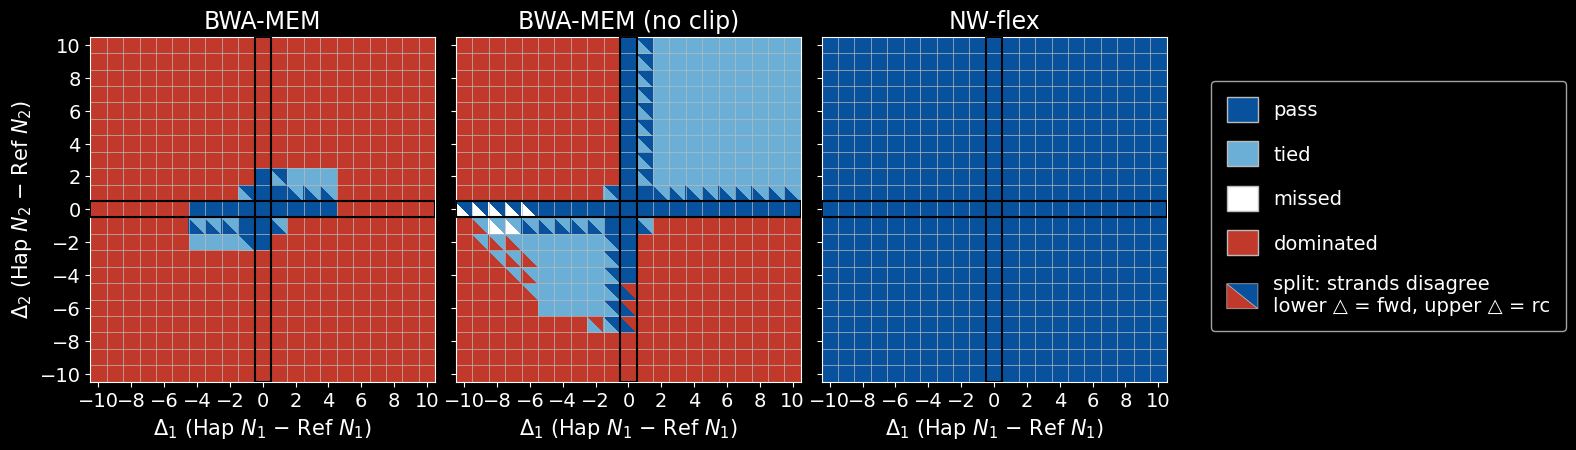

In [113]:
class _SplitCellHandle:
    """Sentinel for the split-cell legend entry (lower △ = fwd, upper △ = rc)."""
    def __init__(self, lower_color, upper_color):
        self.lower_color = lower_color
        self.upper_color = upper_color


def _make_split_cell_handler():
    from matplotlib.legend_handler import HandlerBase
    from matplotlib.patches import Polygon as _Polygon
    class _SplitCellHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent,
                           width, height, fontsize, trans):
            bl = (-xdescent, -ydescent)
            br = (-xdescent + width, -ydescent)
            tl = (-xdescent, -ydescent + height)
            tr = (-xdescent + width, -ydescent + height)
            lower = _Polygon(
                [bl, br, tl], facecolor=orig_handle.lower_color,
                edgecolor="#bbbbbb", linewidth=0.5, transform=trans,
            )
            upper = _Polygon(
                [tr, br, tl], facecolor=orig_handle.upper_color,
                edgecolor="#bbbbbb", linewidth=0.5, transform=trans,
            )
            return [lower, upper]
    return _SplitCellHandler()


def _draw_state_cells(ax, fwd_grid, rc_grid, deltas1, deltas2, color_of):
    from matplotlib.patches import Polygon, Rectangle
    for ri, R in enumerate(deltas2):
        for ci, C in enumerate(deltas1):
            fc = color_of(fwd_grid.iat[ri, ci])
            rc = color_of(rc_grid.iat[ri, ci])
            if fc == rc:
                ax.add_patch(Rectangle(
                    (C - 0.5, R - 0.5), 1, 1,
                    facecolor=fc, edgecolor="none", linewidth=0,
                ))
            else:
                bl = (C - 0.5, R - 0.5)
                br = (C + 0.5, R - 0.5)
                tl = (C - 0.5, R + 0.5)
                tr = (C + 0.5, R + 0.5)
                ax.add_patch(Polygon(
                    [bl, br, tl], facecolor=fc, edgecolor="none",
                    linewidth=0, antialiased=False,
                ))
                ax.add_patch(Polygon(
                    [tr, br, tl], facecolor=rc, edgecolor="none",
                    linewidth=0, antialiased=False,
                ))


def plot_compound_correctness(df, *, deltas1, deltas2, arm_titles,
                              color_pass="#08519c",
                              color_tied="#6baed6",
                              color_missed="#ffffff",
                              color_dominated="#c0392b",
                              color_nan="#cccccc",
                              fontsize=14):
    """2-D version of nwflex.simulation.viz.plot_correctness_heatmap.

    df:          long-form with columns delta1, delta2, arm, fwd_state, rc_state
                 (or just `state`, in which case both triangles share that state).
    deltas1/2:   axis values to display, in left-to-right / bottom-to-top order.
    arm_titles:  ordered mapping arm-key -> panel title.
    """
    from matplotlib.patches import Patch, Rectangle

    deltas1 = list(deltas1)
    deltas2 = list(deltas2)
    arms    = list(arm_titles.keys())
    n       = len(arms)

    label_size = fontsize + 1
    title_size = fontsize + 3

    state_to_color = {
        "P": color_pass, "T": color_tied,
        "M": color_missed, "D": color_dominated,
    }
    def color_of(state):
        if isinstance(state, str) and state in state_to_color:
            return state_to_color[state]
        return color_nan

    has_per_strand = "fwd_state" in df.columns and "rc_state" in df.columns

    fig, axes = plt.subplots(
        1, n, figsize=(5.0 * n + 2.5, 6.0), sharey=True,
        gridspec_kw={"wspace": 0.06},
    )
    if n == 1:
        axes = [axes]

    xticks = [d for d in deltas1 if d % 2 == 0]
    yticks = [d for d in deltas2 if d % 2 == 0]

    for ax, arm in zip(axes, arms):
        sub = df[df["arm"] == arm]
        if has_per_strand:
            fwd_grid = sub.pivot(index="delta2", columns="delta1", values="fwd_state")
            rc_grid  = sub.pivot(index="delta2", columns="delta1", values="rc_state")
        else:
            single = sub.pivot(index="delta2", columns="delta1", values="state")
            fwd_grid = rc_grid = single
        fwd_grid = fwd_grid.reindex(index=deltas2, columns=deltas1)
        rc_grid  = rc_grid.reindex(index=deltas2, columns=deltas1)

        _draw_state_cells(ax, fwd_grid, rc_grid, deltas1, deltas2, color_of)

        ax.set_xlim(deltas1[0] - 0.5, deltas1[-1] + 0.5)
        ax.set_ylim(deltas2[0] - 0.5, deltas2[-1] + 0.5)
        ax.set_aspect("equal")
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_xticks(np.array(deltas1, dtype=float) - 0.5, minor=True)
        ax.set_yticks(np.array(deltas2, dtype=float) - 0.5, minor=True)
        ax.grid(which="minor", color="#bbbbbb", linewidth=0.5)
        ax.tick_params(which="major", labelsize=fontsize)
        ax.tick_params(which="minor", length=0)
        if 0 in deltas1:
            ax.add_patch(Rectangle(
                (-0.5, deltas2[0] - 0.5),
                1, deltas2[-1] - deltas2[0] + 1,
                fill=False, edgecolor="black", linewidth=1.5, zorder=5,
            ))
        if 0 in deltas2:
            ax.add_patch(Rectangle(
                (deltas1[0] - 0.5, -0.5),
                deltas1[-1] - deltas1[0] + 1, 1,
                fill=False, edgecolor="black", linewidth=1.5, zorder=5,
            ))
        ax.set_xlabel(r"$\Delta_1$ (Hap $N_1$ $-$ Ref $N_1$)", fontsize=label_size)
        ax.set_title(arm_titles[arm], fontsize=title_size)
    axes[0].set_ylabel(r"$\Delta_2$ (Hap $N_2$ $-$ Ref $N_2$)", fontsize=label_size)

    legend_handles = [
        Patch(facecolor=color_pass,      edgecolor="#bbbbbb", label="pass"),
        Patch(facecolor=color_tied,      edgecolor="#bbbbbb", label="tied"),
        Patch(facecolor=color_missed,    edgecolor="#bbbbbb", label="missed"),
        Patch(facecolor=color_dominated, edgecolor="#bbbbbb", label="dominated"),
        _SplitCellHandle(lower_color=color_dominated, upper_color=color_pass),
    ]
    legend_labels = [
        "pass", "tied", "missed", "dominated",
        "split: strands disagree\nlower △ = fwd, upper △ = rc",
    ]
    fig.subplots_adjust(right=0.74)
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        handler_map={_SplitCellHandle: _make_split_cell_handler()},
        loc="center left",
        bbox_to_anchor=(0.76, 0.5),
        frameon=True,
        fontsize=fontsize,
        handlelength=1.6,
        handleheight=1.6,
        handletextpad=0.8,
        labelspacing=1.0,
        borderpad=0.8,
    )
    return fig


ARM_TITLES = {
    "std":     "BWA-MEM",
    "no-clip": "BWA-MEM (no clip)",
    "NW-flex": "NW-flex",
}

plot_compound_correctness(
    sweep_df,
    deltas1=DELTAS_1,
    deltas2=DELTAS_2,
    arm_titles=ARM_TITLES,
);

## Effect of bridge length

The bridge-anchoring story predicts that BWA's failure region should shrink as $|M|$ grows: more unique non-repeat sequence between the two blocks gives BWA's seeding stage a clearer anchor, and the local Smith–Waterman extender then has less rope to drift along either block boundary. NW-flex's correctness, in contrast, doesn't depend on $|M|$ — it depends only on the structure of the EP pattern, which is unchanged by the bridge.

We replay the same $(\Delta_1, \Delta_2)$ sweep at four bridge lengths $|M| = 2, 3, 4, 5$, holding everything else fixed (same outer flanks, same motifs, same reference counts $N_1 = N_2 = 10$, same panel rows). Each bridge is composed by the same clean-window mechanism we used above, just with the per-side counts adjusted.

In [114]:
# Bridges of length 2..5.  Each (n1, n2) yields a clean bridge of n1+n2 bp
# composed from cleaned interior segments of the two panel flanks: bridge
# left = first n1 bp of row1's rflank, cleaned against R1; bridge right =
# last n2 bp of row2's lflank, cleaned against R2.
BRIDGE_PAIRS = [(1, 1), (2, 1), (2, 2), (3, 2)]   # |M| = 2, 3, 4, 5

bridge_results = []
for n1, n2 in BRIDGE_PAIRS:
    bl = clean_flank_window(R1, row1["rflank"], n1, side="right")
    br = clean_flank_window(R2, row2["lflank"], n2, side="left")
    M_grid = bl + br
    df_g = run_compound_sweep(M_grid)
    counts = (df_g.groupby("arm")["state"]
              .value_counts().unstack(fill_value=0)
              .reindex(columns=["P", "T", "M", "D"], fill_value=0))
    print(f"|M|={len(M_grid)}  M={M_grid!r}")
    print(counts.to_string())
    print()
    bridge_results.append((M_grid, df_g))

|M|=2  M='CA'
state      P    T  M    D
arm                      
NW-flex  441    0  0    0
no-clip   71  115  0  255
std       25    6  0  410

|M|=3  M='CCA'
state      P  T  M    D
arm                    
NW-flex  441  0  0    0
no-clip   73  1  0  367
std       22  1  0  418

|M|=4  M='CCTA'
state      P  T  M    D
arm                    
NW-flex  441  0  0    0
no-clip  267  1  0  173
std       44  1  0  396

|M|=5  M='CCGTA'
state      P  T  M    D
arm                    
NW-flex  441  0  0    0
no-clip  297  1  0  143
std       45  0  0  396



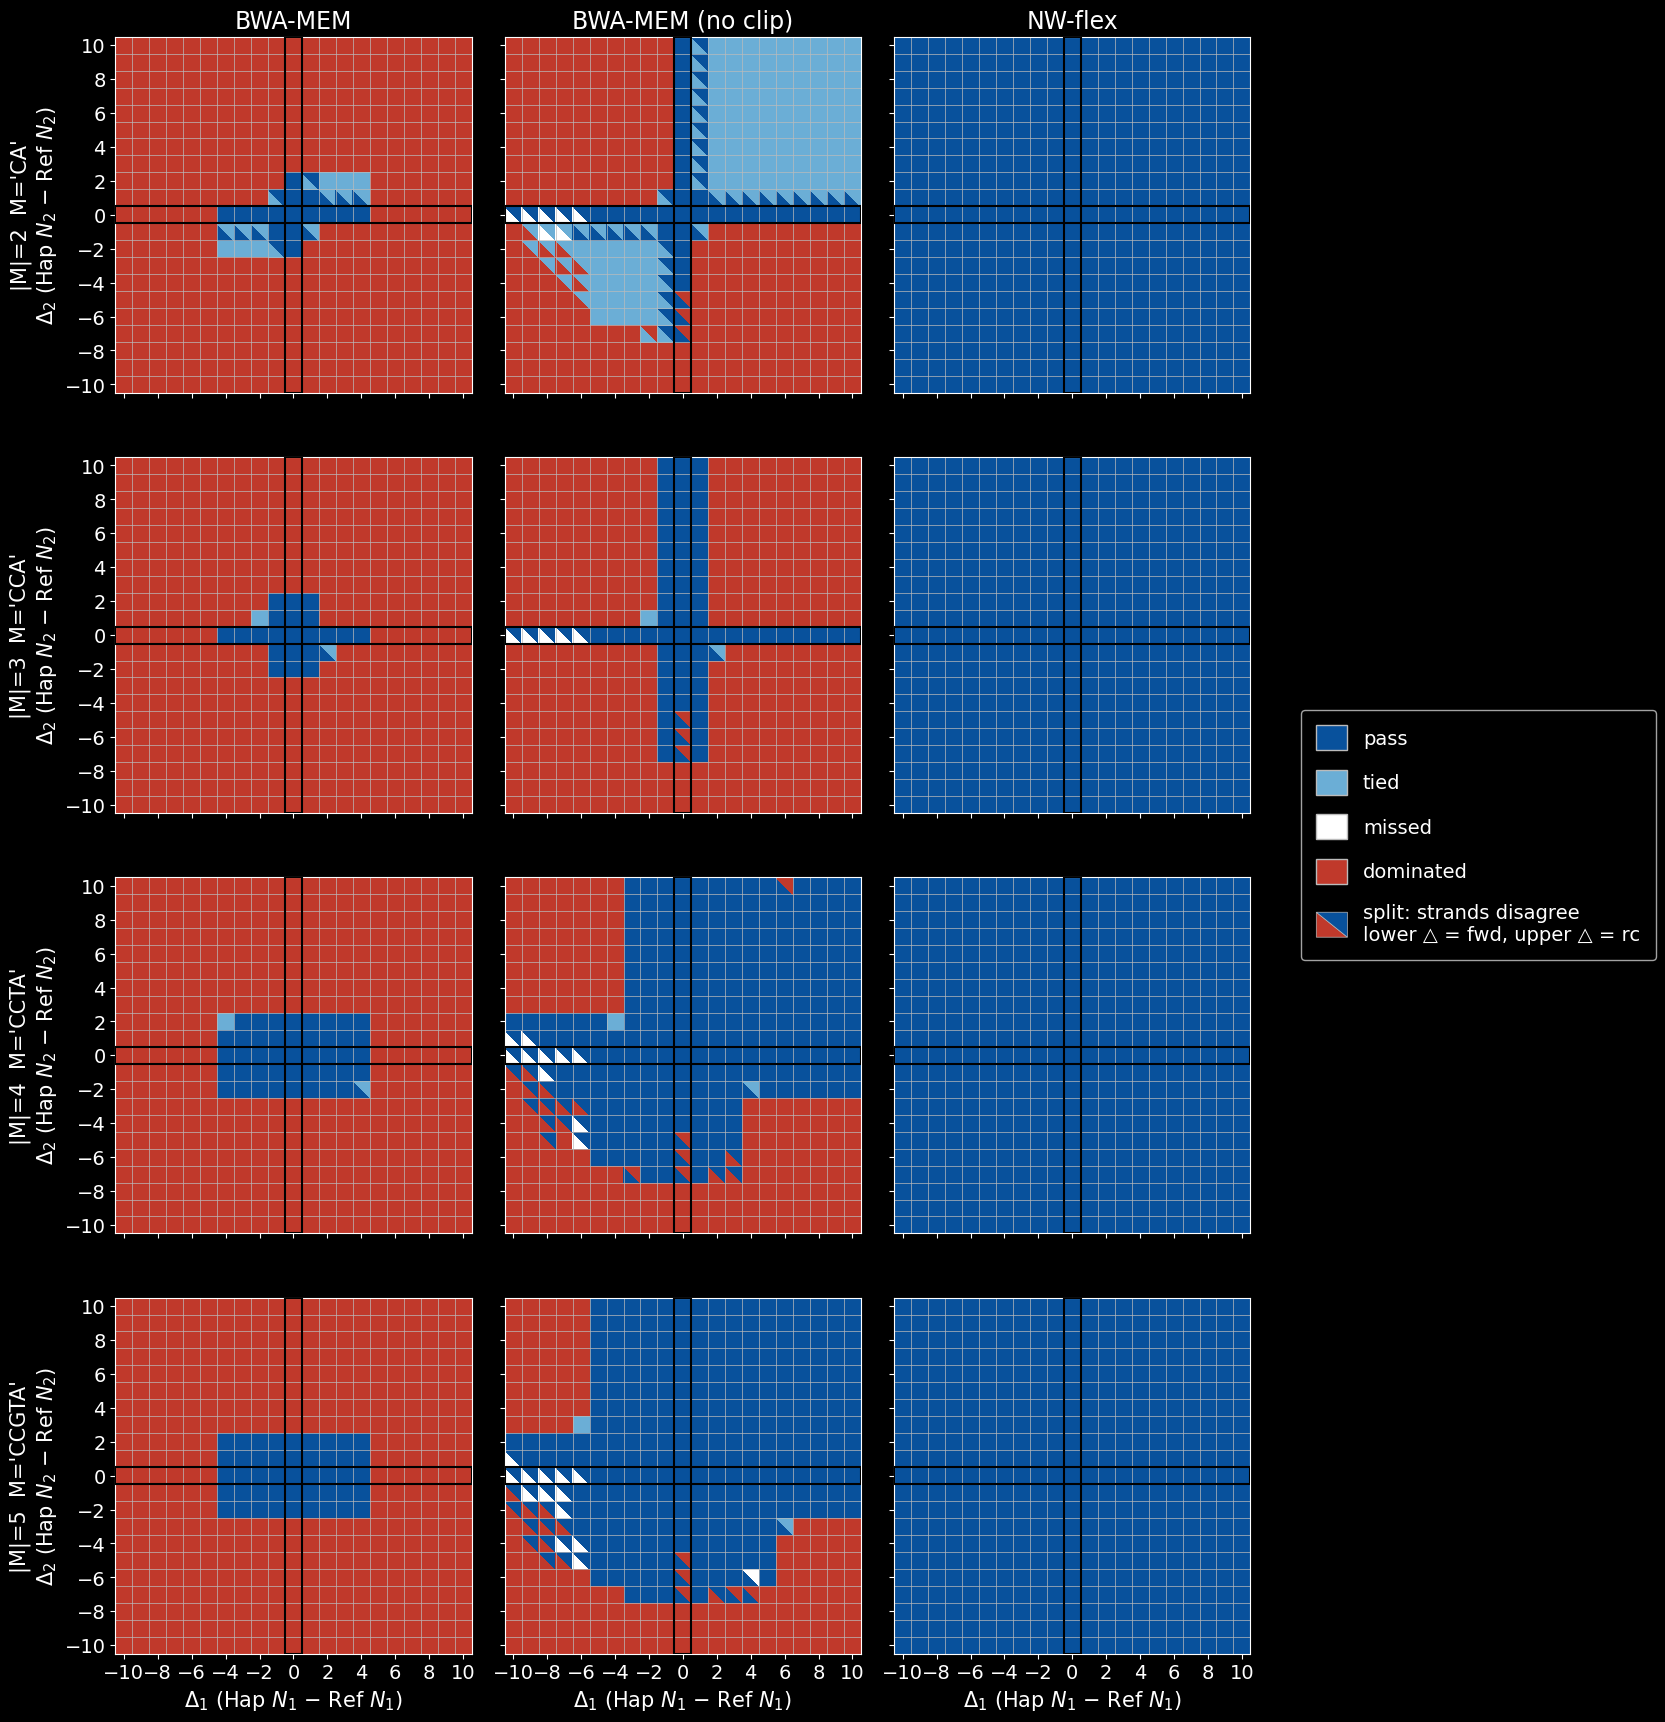

In [115]:
def plot_compound_grid(rows, *, deltas1, deltas2, arm_titles,
                       row_label_fn,
                       color_pass="#08519c",
                       color_tied="#6baed6",
                       color_missed="#ffffff",
                       color_dominated="#c0392b",
                       color_nan="#cccccc",
                       fontsize=14):
    """Multi-row 4-state stack mirroring NB7's plot_correctness_heatmap."""
    from matplotlib.patches import Patch, Rectangle

    deltas1 = list(deltas1)
    deltas2 = list(deltas2)
    arms    = list(arm_titles.keys())
    n_rows  = len(rows)
    n_cols  = len(arms)

    label_size = fontsize + 1
    title_size = fontsize + 3

    state_to_color = {
        "P": color_pass, "T": color_tied,
        "M": color_missed, "D": color_dominated,
    }
    def color_of(state):
        if isinstance(state, str) and state in state_to_color:
            return state_to_color[state]
        return color_nan

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.0 * n_cols + 2.5, 5.0 * n_rows + 1.0),
        sharex=True, sharey=True,
        gridspec_kw={"wspace": 0.06, "hspace": 0.18},
        squeeze=False,
    )

    xticks = [d for d in deltas1 if d % 2 == 0]
    yticks = [d for d in deltas2 if d % 2 == 0]

    for r, (key, df) in enumerate(rows):
        has_per_strand = "fwd_state" in df.columns and "rc_state" in df.columns
        for c, arm in enumerate(arms):
            ax = axes[r, c]
            sub = df[df["arm"] == arm]
            if has_per_strand:
                fwd_grid = sub.pivot(index="delta2", columns="delta1", values="fwd_state")
                rc_grid  = sub.pivot(index="delta2", columns="delta1", values="rc_state")
            else:
                single = sub.pivot(index="delta2", columns="delta1", values="state")
                fwd_grid = rc_grid = single
            fwd_grid = fwd_grid.reindex(index=deltas2, columns=deltas1)
            rc_grid  = rc_grid.reindex(index=deltas2, columns=deltas1)

            _draw_state_cells(ax, fwd_grid, rc_grid, deltas1, deltas2, color_of)

            ax.set_xlim(deltas1[0] - 0.5, deltas1[-1] + 0.5)
            ax.set_ylim(deltas2[0] - 0.5, deltas2[-1] + 0.5)
            ax.set_aspect("equal")
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            ax.set_xticks(np.array(deltas1, dtype=float) - 0.5, minor=True)
            ax.set_yticks(np.array(deltas2, dtype=float) - 0.5, minor=True)
            ax.grid(which="minor", color="#bbbbbb", linewidth=0.5)
            ax.tick_params(which="major", labelsize=fontsize)
            ax.tick_params(which="minor", length=0)
            if 0 in deltas1:
                ax.add_patch(Rectangle(
                    (-0.5, deltas2[0] - 0.5),
                    1, deltas2[-1] - deltas2[0] + 1,
                    fill=False, edgecolor="black", linewidth=1.5, zorder=5,
                ))
            if 0 in deltas2:
                ax.add_patch(Rectangle(
                    (deltas1[0] - 0.5, -0.5),
                    deltas1[-1] - deltas1[0] + 1, 1,
                    fill=False, edgecolor="black", linewidth=1.5, zorder=5,
                ))
            if r == 0:
                ax.set_title(arm_titles[arm], fontsize=title_size)
            if r == n_rows - 1:
                ax.set_xlabel(r"$\Delta_1$ (Hap $N_1$ $-$ Ref $N_1$)",
                              fontsize=label_size)
        axes[r, 0].set_ylabel(
            row_label_fn(key) + "\n" + r"$\Delta_2$ (Hap $N_2$ $-$ Ref $N_2$)",
            fontsize=label_size,
        )

    legend_handles = [
        Patch(facecolor=color_pass,      edgecolor="#bbbbbb", label="pass"),
        Patch(facecolor=color_tied,      edgecolor="#bbbbbb", label="tied"),
        Patch(facecolor=color_missed,    edgecolor="#bbbbbb", label="missed"),
        Patch(facecolor=color_dominated, edgecolor="#bbbbbb", label="dominated"),
        _SplitCellHandle(lower_color=color_dominated, upper_color=color_pass),
    ]
    legend_labels = [
        "pass", "tied", "missed", "dominated",
        "split: strands disagree\nlower △ = fwd, upper △ = rc",
    ]
    fig.subplots_adjust(right=0.78)
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        handler_map={_SplitCellHandle: _make_split_cell_handler()},
        loc="center left",
        bbox_to_anchor=(0.80, 0.5),
        frameon=True,
        fontsize=fontsize,
        handlelength=1.6,
        handleheight=1.6,
        handletextpad=0.8,
        labelspacing=1.0,
        borderpad=0.8,
    )
    return fig


plot_compound_grid(
    bridge_results,
    deltas1=DELTAS_1, deltas2=DELTAS_2,
    arm_titles=ARM_TITLES,
    row_label_fn=lambda M_str: f"|M|={len(M_str)}  M={M_str!r}",
);

## Summary

NW-flex is uniformly correct over the $(\Delta_1, \Delta_2)$ grid by construction. `build_EP_multi_STR_phase` is the row-wise union of per-block phase-preserving EP sets, so for the synthetic geometry $X = A \cdot R_1^{3 N_1} \cdot M \cdot R_2^{3 N_2} \cdot B$ the global DP pass enumerates the Cartesian product of allowed $(N_1 {+} \Delta_1, N_2 {+} \Delta_2)$ counts in one shot. Every cell of the NW-flex panel is correct for the same reason every cell of Notebook 7's NW-flex panel was correct: the algorithm sees the variation as a structural degree of freedom rather than as something to be absorbed by indels and clips.

BWA-MEM has no notion of a repeat block, and with two boundary regions the failure modes compound. The shape of the BWA failure region depends on at least three parameters that the present figure holds fixed: the **similarity between the two motifs** (more shared substructure → more seed ambiguity at the boundary), the **bridge length** $|M|$ (longer bridge → more unique anchor between the blocks → fewer failures), and the **absolute repeat counts** $N_1, N_2$ (larger blocks → more rope for local Smith–Waterman to drift). A larger sweep across these axes is left to the harness scripts in our internal compound work; the present notebook is the per-locus structural picture.